<a href="https://colab.research.google.com/github/giu-mzx/Checkpoint_02_SERS/blob/main/parte_4_desafio_final/Desafio_Tarefa_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Grupo:**

Andrey Crence Fernandes - RM 573840

Giulliana Maistro Brasolin - RM 569381

Mikaella Mirela Dos Santos Lucindo - RM 573775

Lara Dos Santos Cândido Alves - RM 573827

Lucas Parkin Devito - RM 573251

## **Tarefa 1 — Classificação (ANEEL)**

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score


* Carregue o CSV, confira os tipos das colunas, as contagens por classe, valores ausentes e distribuições relevantes. Explique X (três entradas) e y (fonte).
* Faça uma divisão estratificada de treino/teste, por exemplo 80%/20%, com semente fixa. Ajustes de escala aprendidos dos dados devem ser feitos somente com o treino.
* Escolha, justifique e treine três classificadores diferentes usando a mesma divisão. Eles não estão importados nem implementados neste notebook.
* Compare Accuracy, Precision, Recall e F1. Declare o tipo de média usado nas métricas por classe (por exemplo, macro) e apresente a matriz de confusão.
* Explique qual modelo escolheria, quais classes ele mais confunde e por que potência/localização podem não bastar para uma aplicação real. Não use SigTipoGeracao, nomes, CEG ou descrições da fonte como entradas.

In [19]:
df = pd.read_csv("https://raw.githubusercontent.com/giu-mzx/Checkpoint_02_SERS/refs/heads/main/datasets/aneel_classificacao_orange.csv")

print("Formato (linhas, colunas):", df.shape)
df.head()

Formato (linhas, colunas): (3876, 4)


,potencia_kw,latitude,longitude,fonte
0,20.48,-10.442778,-64.151944,Solar
1,5000.00,-6.003889,-40.274722,Solar
2,12.26,-23.557778,-46.734000,Solar
3,3.00,-23.558889,-46.735000,Solar
4,1.70,-23.493819,-46.845000,Solar


## **Tipos das colunas**

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3876 entries, 0 to 3875
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   potencia_kw  3876 non-null   float64
 1   latitude     3876 non-null   float64
 2   longitude    3876 non-null   float64
 3   fonte        3876 non-null   object 
dtypes: float64(3), object(1)
memory usage: 121.3+ KB


## **Contagem de exemplos por classe**

            quantidade  porcentagem (%)
fonte                                  
Hidráulica        1476             38.1
Solar             1200             31.0
Eólica            1200             31.0


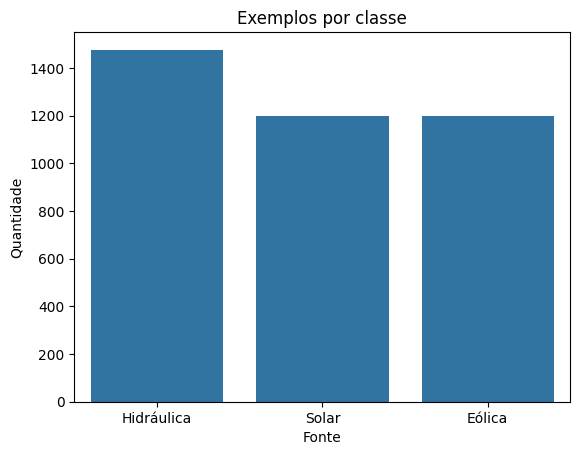

In [21]:
contagem = df["fonte"].value_counts()
porcentagem = df["fonte"].value_counts(normalize=True).mul(100).round(1)
print(pd.DataFrame({"quantidade": contagem, "porcentagem (%)": porcentagem}))

sns.countplot(data=df, x="fonte", order=contagem.index)
plt.title("Exemplos por classe")
plt.xlabel("Fonte")
plt.ylabel("Quantidade")
plt.show()

Antes da limpeza, a Hidráulica tinha 1.476 exemplos (38,1%) e Solar e Eólica tinham 1.200 cada (31,0%). Solar e Eólica têm exatamente 1.200 porque a consulta à API foi limitada a 1.200 linhas por tipo, então o equilíbrio é em parte artificial. As classes são razoavelmente equilibradas, por isso a Accuracy é uma métrica aceitável, e usamos a média macro para as demais.

## **Valores ausentes por coluna**

In [22]:
ausentes = df.isnull().sum()
print(ausentes)
print()
print("Há valores ausentes?", "Sim" if ausentes.sum() > 0 else "Não")

potencia_kw    0
latitude       0
longitude      0
fonte          0
dtype: int64

Há valores ausentes? Não


In [23]:
display(df.describe())
display(df.groupby("fonte")[["potencia_kw", "latitude", "longitude"]].describe().T)

,potencia_kw,latitude,longitude
count,3.876000e+03,3876.000000,3876.000000
mean,4.201468e+04,-12.693951,-46.158299
std,3.016366e+05,9.500523,8.357453
min,1.600000e-01,-33.722806,-69.941389
25%,4.400000e+02,-21.142110,-52.561817
50%,1.268000e+04,-10.469532,-47.393697
75%,3.000000e+04,-4.127788,-41.280013
max,1.123310e+07,3.831392,0.000000


fonte                     Eólica    Hidráulica          Solar
potencia_kw count    1200.000000  1.476000e+03    1200.000000
            mean    30782.769883  7.580916e+04   11679.386733
            std     13800.597800  4.864196e+05   18374.855154
            min         0.160000  9.900000e-01       0.260000
            25%     23100.000000  9.900000e+02       1.000000
            50%     29600.000000  4.000000e+03       1.000000
            75%     37200.000000  1.700000e+04   28880.000000
            max    105000.000000  1.123310e+07  137480.000000
latitude    count    1200.000000  1.476000e+03    1200.000000
            mean       -9.896436 -2.111301e+01      -5.136029
            std         7.529853  6.500423e+00       5.546914
            min       -33.722806 -3.078799e+01     -29.835550
            25%       -11.136206 -2.675362e+01      -6.924585
            50%        -7.986274 -2.203073e+01      -2.055540
            75%        -5.271434 -1.760462e+01      -1.831473
            max         0.000000  3.801667e+00       3.831392
longitude   count    1200.000000  1.476000e+03    1200.000000
            mean      -39.715921 -4.893246e+01     -49.188463
            std         7.231867  7.976908e+00       5.912291
            min       -55.930850 -6.464614e+01     -69.941389
            25%       -41.865407 -5.263224e+01     -53.067800
            50%       -40.692088 -5.041888e+01     -52.440865
            75%       -36.491659 -4.619944e+01     -44.881156
            max         0.000000  0.000000e+00     -35.235400

## **Distribuições relevantes**

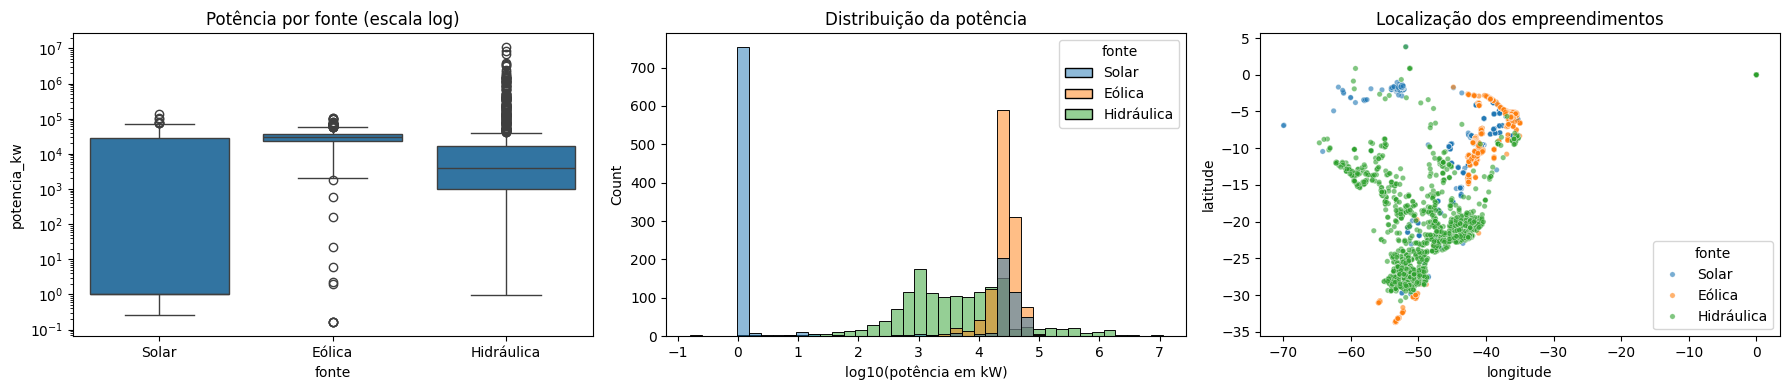

In [24]:
fig, eixos = plt.subplots(1, 3, figsize=(18, 4))

sns.boxplot(data=df, x="fonte", y="potencia_kw", ax=eixos[0])
eixos[0].set_yscale("log")
eixos[0].set_title("Potência por fonte (escala log)")

sns.histplot(data=df, x=np.log10(df["potencia_kw"].clip(lower=1e-3)),
             hue="fonte", bins=40, ax=eixos[1])
eixos[1].set_xlabel("log10(potência em kW)")
eixos[1].set_title("Distribuição da potência")

sns.scatterplot(data=df, x="longitude", y="latitude", hue="fonte",
                alpha=0.6, s=15, ax=eixos[2])
eixos[2].set_title("Localização dos empreendimentos")

plt.tight_layout()
plt.show()

## **Explicação de X e y:**

* X (entradas): as três colunas numéricas — `potencia_kw`, `latitude` e `longitude`.
* y (alvo): a coluna `fonte`, com três classes: Solar, Eólica e Hidráulica. Como é uma categoria, o problema é de classificação.
* Colunas como `SigTipoGeracao`, nome do empreendimento e CEG não entram em X, porque poderiam "entregar" a resposta.

Observações: A potência não diferencia totalmente as classes, pois há sobreposição entre elas. A eólica tem potências mais concentradas, a hidráulica apresenta grande variação e a solar possui muitos empreendimentos de baixa potência. A localização também ajuda a diferenciar: a hidráulica se concentra no Sul e Sudeste, a eólica no Nordeste e a solar principalmente no Norte e Nordeste, mas há sobreposição entre as regiões, o que gera confusões entre as classes. Foram identificados 47 empreendimentos (24 Eólica e 23 Hidráulica) com latitude e longitude iguais a 0, provavelmente coordenadas não preenchidas no cadastro. Como não são localizações reais, essas linhas foram removidas antes da divisão entre treino e teste, restando 3.829 linhas.


In [25]:
# Empreendimentos com latitude e longitude iguais a 0 (coordenadas não preenchidas).
sem_coordenada = (df["latitude"] == 0) & (df["longitude"] == 0)
print("Linhas com coordenadas (0, 0):", sem_coordenada.sum())
print(df[sem_coordenada]["fonte"].value_counts())

# Removendo essas linhas antes de separar X e y.
df = df[~sem_coordenada]
print("Linhas restantes:", df.shape[0])

Linhas com coordenadas (0, 0): 47
fonte
Eólica        24
Hidráulica    23
Name: count, dtype: int64
Linhas restantes: 3829


## **Separação X e y**

In [26]:
X = df[["potencia_kw", "latitude", "longitude"]]
y = df["fonte"]

display(X.head())
display(y.head())

,potencia_kw,latitude,longitude
0,20.48,-10.442778,-64.151944
1,5000.00,-6.003889,-40.274722
2,12.26,-23.557778,-46.734000
3,3.00,-23.558889,-46.735000
4,1.70,-23.493819,-46.845000


,fonte
0,Solar
1,Solar
2,Solar
3,Solar
4,Solar


## **Treino/teste**

In [27]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f"Treino: {X_treino.shape[0]} registros")
print(f"Teste:  {X_teste.shape[0]} registros")

Treino: 3063 registros
Teste:  766 registros


## **Conferindo se as classes ficaram parecidas nos três conjuntos**

In [28]:
proporcoes = pd.DataFrame({
    "completo (%)": y.value_counts(normalize=True).mul(100).round(1),
    "treino (%)":   y_treino.value_counts(normalize=True).mul(100).round(1),
    "teste (%)":    y_teste.value_counts(normalize=True).mul(100).round(1),
})
proporcoes

,completo (%),treino (%),teste (%)
fonte,,,
Hidráulica,37.9,37.9,38.0
Solar,31.3,31.3,31.3
Eólica,30.7,30.7,30.7


In [29]:
escala = StandardScaler()
escala.fit(X_treino)

X_treino_esc = escala.transform(X_treino)
X_teste_esc  = escala.transform(X_teste)

print("Médias aprendidas no treino:", escala.mean_.round(3))
print("Desvios aprendidos no treino:", escala.scale_.round(3))

Médias aprendidas no treino: [ 4.155133e+04 -1.290500e+01 -4.673600e+01]
Desvios aprendidos no treino: [3.22544122e+05 9.54100000e+00 6.68300000e+00]


# Três classificadores

Regressão Logística: modelo simples usado como base. Utiliza dados padronizados para evitar problemas com diferenças de escala.



Árvore de Decisão: classifica os dados por regras e não precisa de padronização.



KNN: classifica com base nos exemplos mais próximos. Usa dados padronizados, pois depende de distâncias.

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

modelos = {
    "Regressão Logística": (LogisticRegression(max_iter=1000, random_state=42), X_treino_esc, X_teste_esc),
    "Árvore de Decisão":   (DecisionTreeClassifier(random_state=42), X_treino, X_teste),
    "KNN":                 (KNeighborsClassifier(n_neighbors=5), X_treino_esc, X_teste_esc),
}

previsoes = {}
for nome, (modelo, Xtr, Xte) in modelos.items():
    modelo.fit(Xtr, y_treino)
    previsoes[nome] = modelo.predict(Xte)
    print(f"{nome}: treinado")

Regressão Logística: treinado
Árvore de Decisão: treinado
KNN: treinado


## **Comparação dos modelos**



In [31]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

linhas = []
for nome, y_prev in previsoes.items():
    linhas.append({
        "Modelo": nome,
        "Accuracy": accuracy_score(y_teste, y_prev),
        "Precision (macro)": precision_score(y_teste, y_prev, average="macro", zero_division=0),
        "Recall (macro)": recall_score(y_teste, y_prev, average="macro", zero_division=0),
        "F1 (macro)": f1_score(y_teste, y_prev, average="macro", zero_division=0),
    })

tabela = pd.DataFrame(linhas).set_index("Modelo").round(3)
display(tabela)

,Accuracy,Precision (macro),Recall (macro),F1 (macro)
Modelo,,,,
Regressão Logística,0.830,0.837,0.829,0.826
Árvore de Decisão,0.967,0.967,0.968,0.967
KNN,0.960,0.960,0.959,0.959


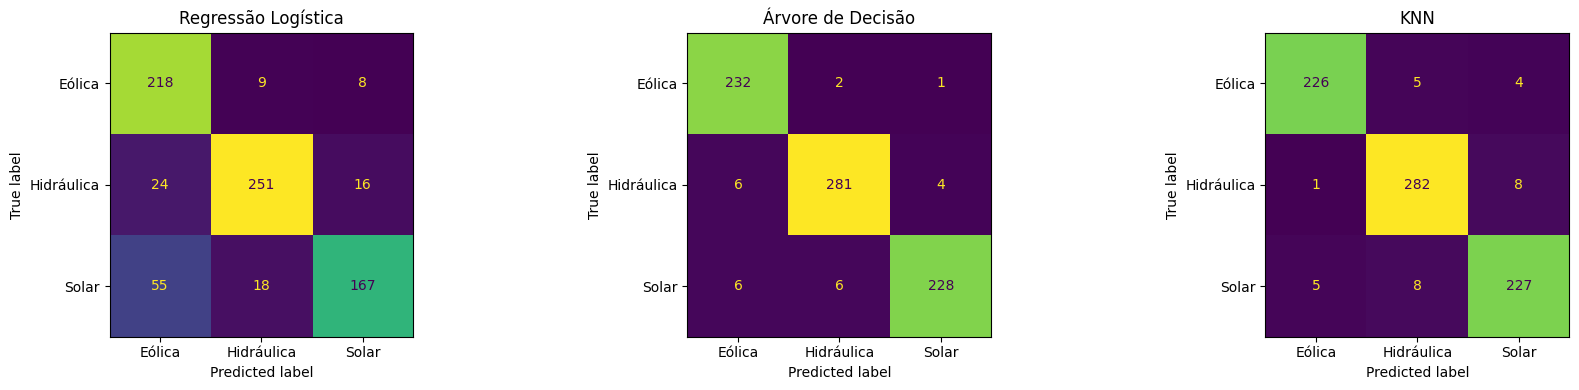

In [32]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

classes = sorted(y.unique())
fig, eixos = plt.subplots(1, 3, figsize=(18, 4))

for eixo, (nome, y_prev) in zip(eixos, previsoes.items()):
    cm = confusion_matrix(y_teste, y_prev, labels=classes)
    ConfusionMatrixDisplay(cm, display_labels=classes).plot(ax=eixo, colorbar=False)
    eixo.set_title(nome)

plt.tight_layout()
plt.show()

In [33]:
# Teste extra: só localização x só potência (Árvore de Decisão).
for colunas in (["latitude", "longitude"], ["potencia_kw"]):
    arvore = DecisionTreeClassifier(random_state=42)
    arvore.fit(X_treino[colunas], y_treino)
    acc = accuracy_score(y_teste, arvore.predict(X_teste[colunas]))
    print(colunas, "-> accuracy:", round(acc, 3))

['latitude', 'longitude'] -> accuracy: 0.962
['potencia_kw'] -> accuracy: 0.815


## **Interpretação**
* Modelo escolhido: A Árvore de Decisão apresentou o melhor resultado (accuracy e F1 macro de 0,967), seguida de perto pelo KNN (0,960). A diferença é de apenas 6 casos entre os 766 do teste. A Regressão Logística ficou bem abaixo (0,830), pois traça fronteiras lineares e as fontes se agrupam por região. Escolheria a Árvore por ter o melhor resultado, ser simples de explicar e não depender de padronização.

* Classes mais confundidas: Na Árvore de Decisão, 6 empreendimentos Hidráulicos foram previstos como Eólicos, 6 Solares como Eólicos e 6 Solares como Hidráulicos. Somando os dois sentidos, o par mais confundido foi Solar e Hidráulica (10 casos). A Regressão Logística errou principalmente ao prever como Eólica empreendimentos que eram Solar (55 casos).

* Limitações: A potência e a localização não são suficientes para identificar todas as fontes de energia, pois fontes diferentes podem ter características parecidas. Outras informações, como a tecnologia da usina e os recursos naturais da região, poderiam melhorar os resultados.
Em um teste extra, a Árvore de Decisão chegou a 0,962 de accuracy usando só latitude e longitude, e a 0,815 usando só a potência. A localização carrega quase toda a informação, provavelmente porque usinas da mesma fonte ficam agrupadas em regiões próximas. Assim, o modelo aprende onde cada fonte costuma estar e pode não funcionar bem para um local novo. Além disso, a potência é a capacidade outorgada, não a energia gerada, e 64% dos empreendimentos solares têm até 10 kW, o que mostra que o cadastro mistura projetos de portes muito diferentes.